In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
Loading the dataset

In [21]:
df = pd.read_csv("dataset.csv")

In [22]:
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [ ]:
EDA part

In [23]:
df.shape


(114000, 21)

In [24]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [26]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [27]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


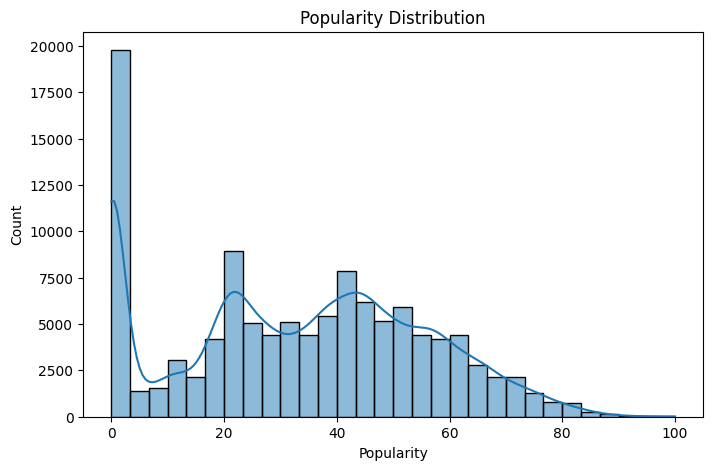

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["popularity"], bins=30, kde=True)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()


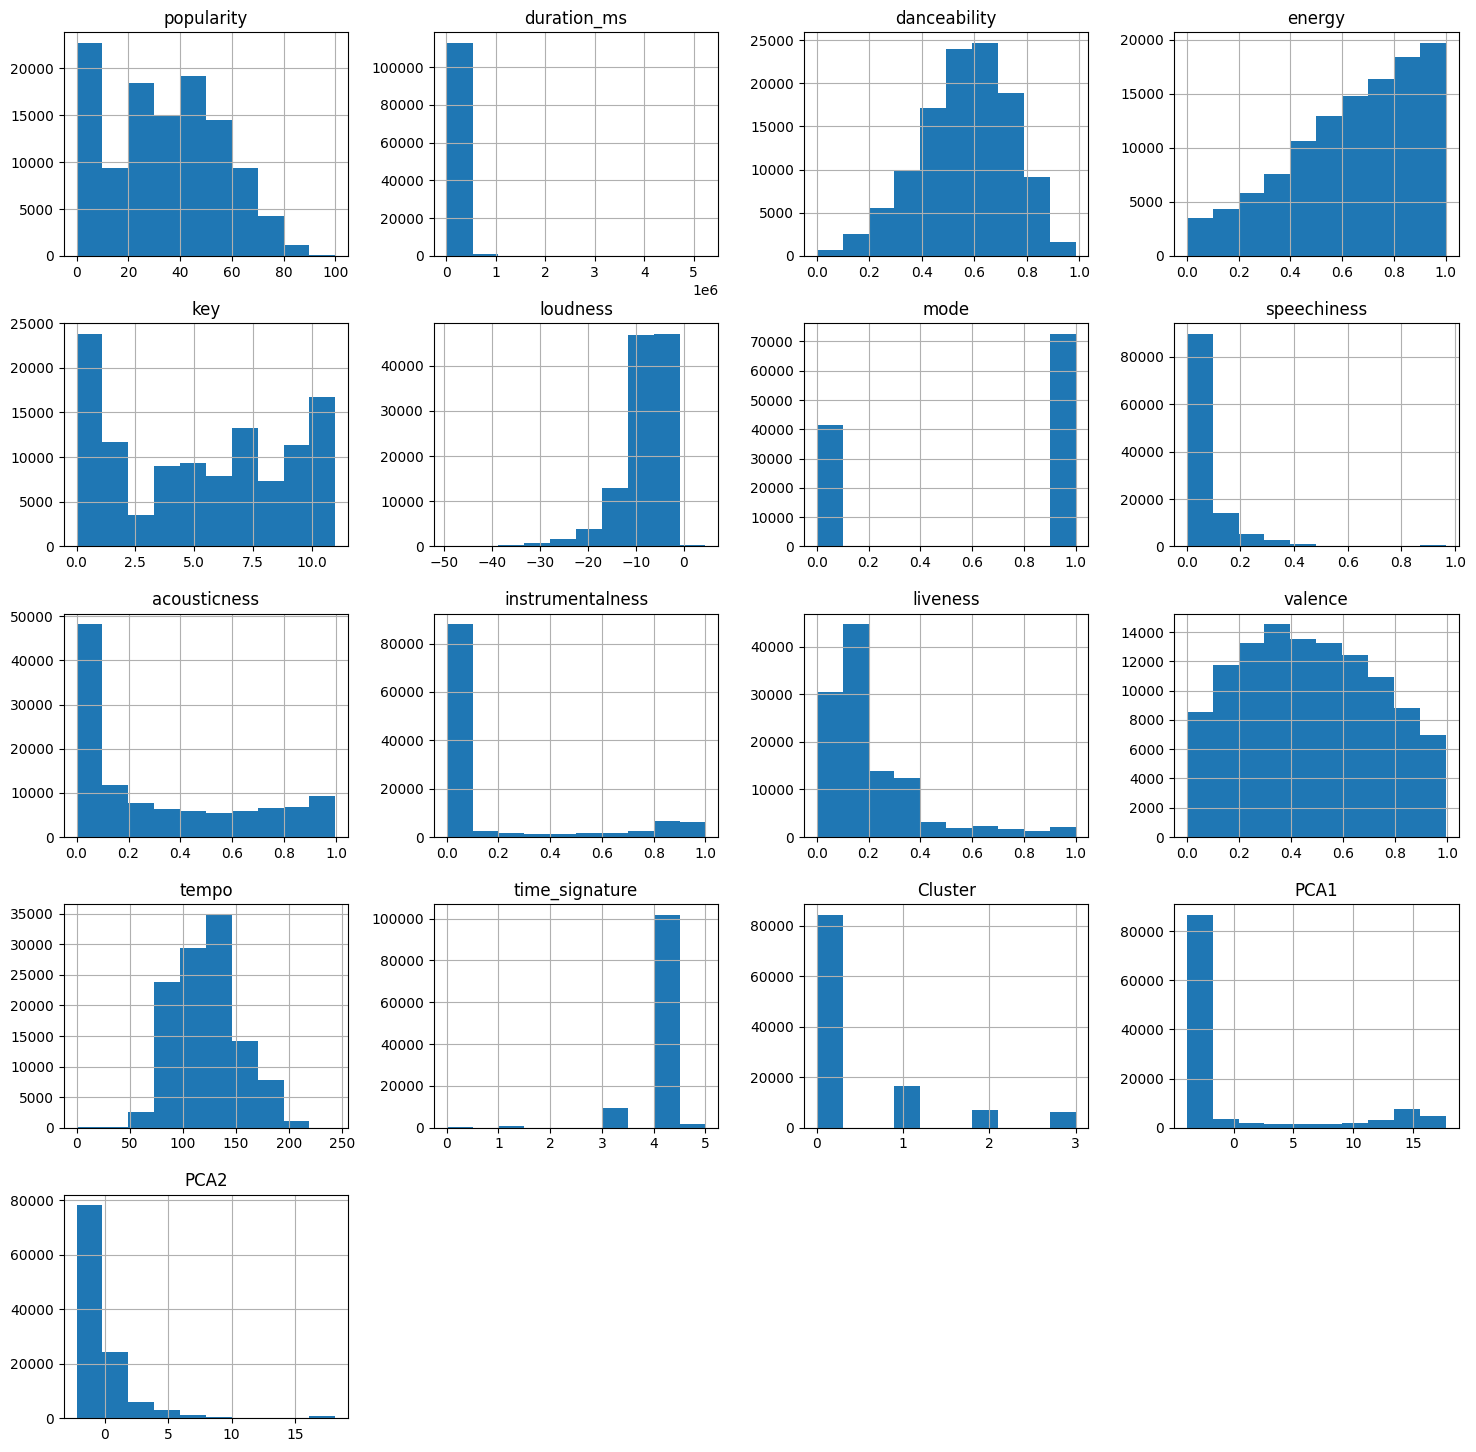

In [46]:
df.hist(figsize=(18, 18)) #histogram
plt.show()

In [ ]:
Data preprocessing and Data cleaning

In [29]:
df = df.drop("Unnamed: 0", axis=1)
df = df.dropna(subset=["artists", "album_name", "track_name"])

In [33]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df[features]

In [45]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

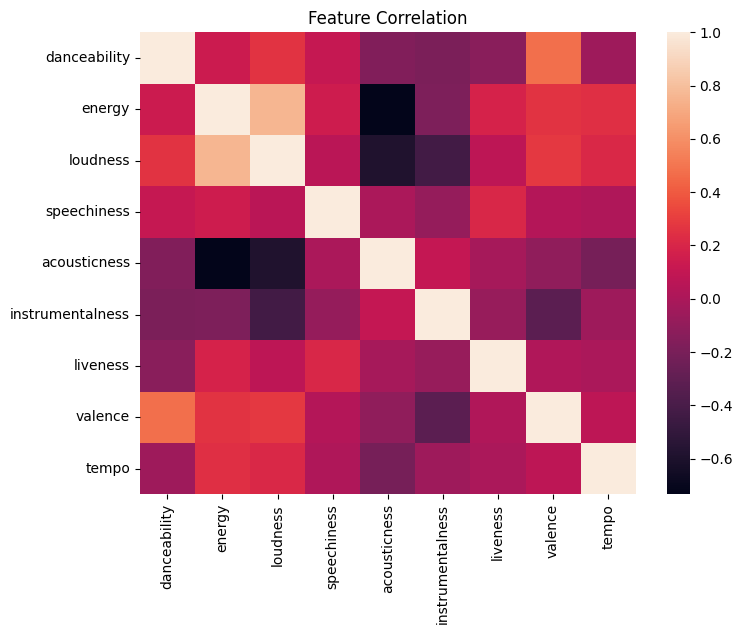

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=False)
plt.title("Feature Correlation")
plt.show()

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,Cluster
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,0


In [37]:
final_silhouette = silhouette_score(X_scaled, df["Cluster"], sample_size=5000, random_state=42)
final_davies = davies_bouldin_score(X_scaled, df["Cluster"])
final_calinski = calinski_harabasz_score(X_scaled, df["Cluster"])

print("Final KMeans Model Evaluation")
print("Silhouette Score:", final_silhouette)
print("Davies-Bouldin Score:", final_davies)
print("Calinski-Harabasz Score:", final_calinski)

Final KMeans Model Evaluation
Silhouette Score: 0.5681665522740461
Davies-Bouldin Score: 0.7853516503207223
Calinski-Harabasz Score: 223398.08638015654


In [38]:
counts = df["Cluster"].value_counts().sort_index()
counts

Cluster
0    84282
1    16553
2     6902
3     6262
Name: count, dtype: int64

In [39]:
cluster_profile = df.groupby("Cluster")[features].mean().round(3)
cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,
0,0.576,0.657,-7.284,0.063,0.301,0.009,0.214,0.513,122.738
1,0.496,0.524,-13.356,0.064,0.414,0.858,0.178,0.291,118.198
2,0.648,0.692,-7.475,0.406,0.332,0.007,0.296,0.525,122.373
3,0.538,0.684,-8.769,0.072,0.220,0.436,0.206,0.374,124.389


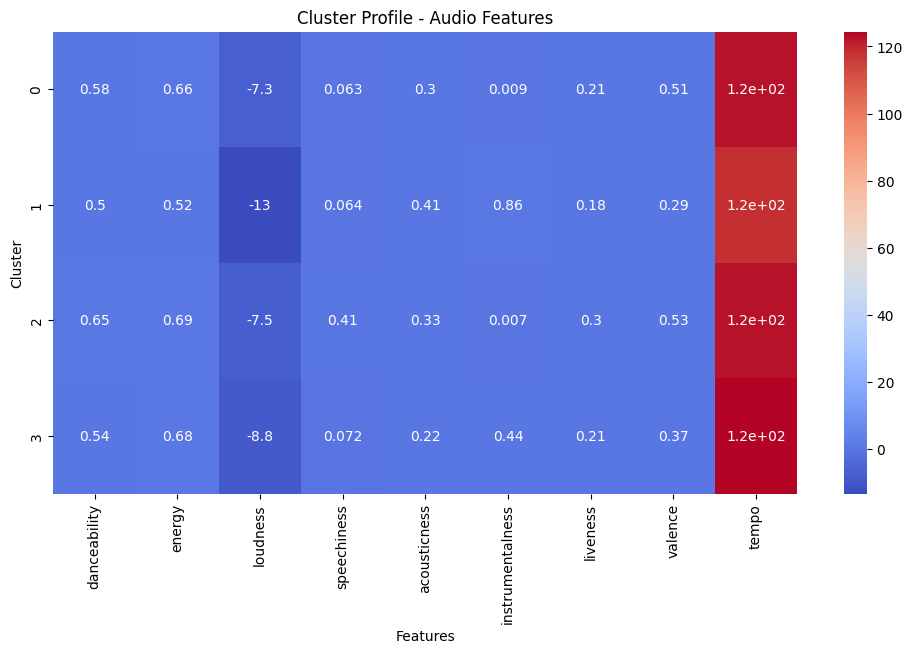

In [40]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile, annot=True, cmap="coolwarm")

plt.title("Cluster Profile - Audio Features")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

In [41]:
for c in sorted(df["Cluster"].unique()):
  print("\n==============================")
  print("Cluster", c)
  top_songs = df[df["Cluster"] == c].sort_values("popularity", ascending=False).head(5)
  display(top_songs[["track_name", "artists", "track_genre", "popularity"]])


Cluster 0


,track_name,artists,track_genre,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,pop,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
67356,La Bachata,Manuel Turizo,latin,98
88410,La Bachata,Manuel Turizo,reggae,98



Cluster 1


,track_name,artists,track_genre,popularity
31050,everything i wanted,Billie Eilish,electro,86
101376,Clean White Noise - Loopable with no fade,White Noise Baby Sleep;White Noise for Babies,sleep,85
57303,YKWIM?,Yot Club,indie,84
56155,YKWIM?,Yot Club,indie-pop,84
38024,Alien Blues,Vundabar,garage,82



Cluster 2


,track_name,artists,track_genre,popularity
89405,Tití Me Preguntó,Bad Bunny,reggaeton,97
88407,Tití Me Preguntó,Bad Bunny,reggae,97
68304,Tití Me Preguntó,Bad Bunny,latino,97
67359,Tití Me Preguntó,Bad Bunny,latin,97
51458,Super Freaky Girl,Nicki Minaj,hip-hop,92



Cluster 3


,track_name,artists,track_genre,popularity
86000,Freaks,Surf Curse,punk,86
56051,Freaks,Surf Curse,indie-pop,86
57054,Freaks,Surf Curse,indie,86
57004,Apocalypse,Cigarettes After Sex,indie,84
56003,Apocalypse,Cigarettes After Sex,indie-pop,84


In [42]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

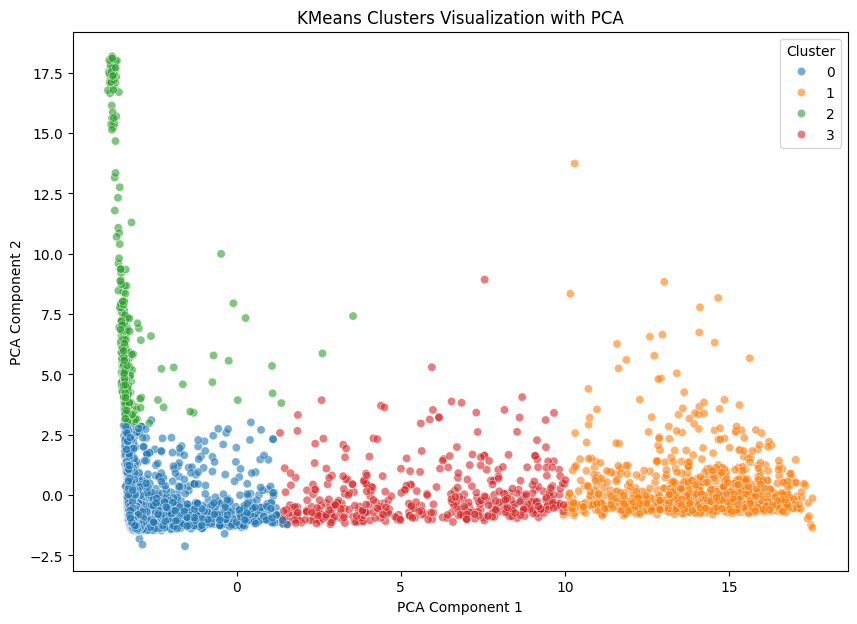

In [44]:
df_sample = df.sample(8000, random_state=42)
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_sample,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("KMeans Clusters Visualization with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()